In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve, confusion_matrix, classification_report

print(f"✅ Imports OK | PyTorch : {torch.__version__}")

✅ Imports OK | PyTorch : 2.10.0+cpu


In [2]:
X_train = np.load("../data/X_train_res.npy")
y_train = np.load("../data/y_train_res.npy")
X_test = np.load("../data/X_test.npy")
y_test = np.load("../data/y_test.npy")

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Fraudes train : {y_train.sum()} | Fraudes test : {y_test.sum()}")

Train : (68235, 29) | Test : (56962, 29)
Fraudes train : 22745 | Fraudes test : 98


In [9]:
def build_transaction_graph(X, y, n_neighbors=5):
    from sklearn.neighbors import NearestNeighbors
    
    print(f"Construction du graphe sur {len(X)} transactions...")
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, n_jobs=-1)
    nbrs.fit(X)
    distances, indices = nbrs.kneighbors(X)
    
    edge_index = []
    for i, neighbors in enumerate(indices):
        for j in neighbors[1:]:
            edge_index.append([i, j])
            edge_index.append([j, i])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.FloatTensor(X)
    y_tensor = torch.LongTensor(y.astype(int))
    
    data = Data(x=x, edge_index=edge_index, y=y_tensor)
    print(f"✅ Graphe créé : {data.num_nodes} noeuds, {data.num_edges} arêtes")
    return data

# Train : 5000 échantillons
N_SAMPLE = 5000
idx = np.random.choice(len(X_train), N_SAMPLE, replace=False)
X_sample = X_train[idx]
y_sample = y_train[idx]

data_train = build_transaction_graph(X_sample, y_sample)

# Test : on garde TOUTES les fraudes + échantillon normal
fraud_idx = np.where(y_test == 1)[0]
normal_idx = np.where(y_test == 0)[0][:2000]
test_idx = np.concatenate([fraud_idx, normal_idx])

X_test_gnn = X_test[test_idx]
y_test_gnn = y_test[test_idx]

data_test = build_transaction_graph(X_test_gnn, y_test_gnn)
print(f"Fraudes dans le test GNN : {y_test_gnn.sum()}")

Construction du graphe sur 5000 transactions...
✅ Graphe créé : 5000 noeuds, 40000 arêtes
Construction du graphe sur 2098 transactions...
✅ Graphe créé : 2098 noeuds, 16784 arêtes
Fraudes dans le test GNN : 98


In [10]:
class FraudGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=2):
        super(FraudGNN, self).__init__()
        
        # Graph Attention Layers
        self.conv1 = GATConv(input_dim, hidden_dim, heads=4, dropout=0.3)
        self.conv2 = GATConv(hidden_dim * 4, hidden_dim, heads=1, dropout=0.3)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        
        return self.classifier(x)

model_gnn = FraudGNN(input_dim=X_train.shape[1])
print(model_gnn)
print(f"\n✅ GNN créé !")

FraudGNN(
  (conv1): GATConv(29, 64, heads=4)
  (conv2): GATConv(256, 64, heads=1)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

✅ GNN créé !


Class weights : tensor([1.0000, 1.9070])
Epoch 20/100 | Loss : 0.2785 | Acc : 0.9064
Epoch 40/100 | Loss : 0.1295 | Acc : 0.9642
Epoch 60/100 | Loss : 0.0969 | Acc : 0.9700
Epoch 80/100 | Loss : 0.0826 | Acc : 0.9744
Epoch 100/100 | Loss : 0.0712 | Acc : 0.9758


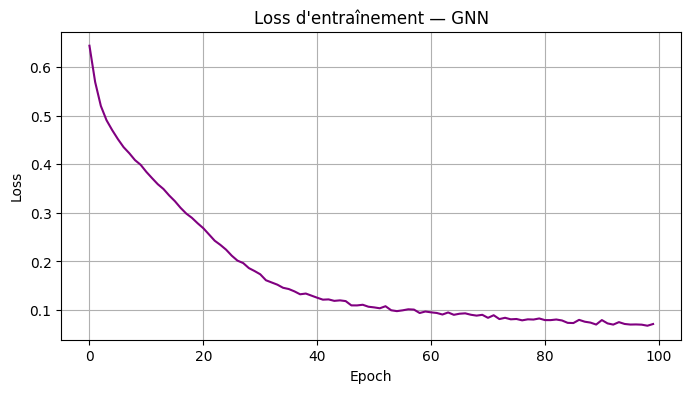

In [11]:
# Gestion du déséquilibre avec class weights
class_counts = np.bincount(y_sample.astype(int))
class_weights = torch.FloatTensor([1.0, class_counts[0]/class_counts[1]])
print(f"Class weights : {class_weights}")

optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

EPOCHS = 100
losses = []

for epoch in range(EPOCHS):
    model_gnn.train()
    optimizer.zero_grad()
    
    out = model_gnn(data_train)
    loss = criterion(out, data_train.y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        # Accuracy sur train
        pred = out.argmax(dim=1)
        acc = (pred == data_train.y).float().mean()
        print(f"Epoch {epoch+1}/{EPOCHS} | Loss : {loss.item():.4f} | Acc : {acc:.4f}")

plt.figure(figsize=(8,4))
plt.plot(losses, color='purple')
plt.title("Loss d'entraînement — GNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

Fraudes dans le test : 98
AUPRC GNN : 0.9130

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      2000
      Fraude       0.66      0.88      0.75        98

    accuracy                           0.97      2098
   macro avg       0.83      0.93      0.87      2098
weighted avg       0.98      0.97      0.97      2098



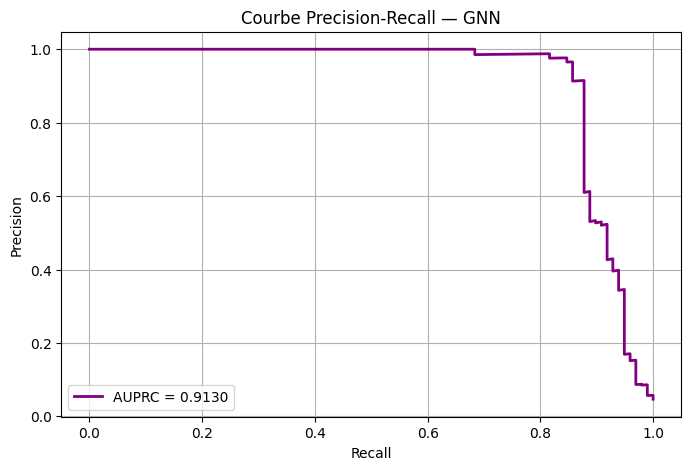


Fraudes détectées : 86/98
Faux Positifs : 45
Faux Négatifs : 12
Coût financier estimé : 6450€


In [12]:
model_gnn.eval()
with torch.no_grad():
    out = model_gnn(data_test)
    probs = F.softmax(out, dim=1)[:, 1].numpy()
    y_pred = out.argmax(dim=1).numpy()
    y_true = data_test.y.numpy()

print(f"Fraudes dans le test : {y_true.sum()}")

auprc = average_precision_score(y_true, probs)
print(f"AUPRC GNN : {auprc:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['Normal', 'Fraude'])}")

precision, recall, _ = precision_recall_curve(y_true, probs)
plt.figure(figsize=(8,5))
plt.plot(recall, precision, color='purple', lw=2, label=f'AUPRC = {auprc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — GNN')
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_true, y_pred)
TN, FP, FN, TP = cm.ravel()
cout_total = (FP * 10) + (FN * 500)
print(f"\nFraudes détectées : {TP}/{y_true.sum()}")
print(f"Faux Positifs : {FP}")
print(f"Faux Négatifs : {FN}")
print(f"Coût financier estimé : {cout_total}€")